# Baseball Pitch Identification - Supervised Learning
## SIADS 696 Milestone II
**Author:** Ian MacKinnon  
**Dataset:** MLB Statcast 2023-2025 via pybaseball  
**Goal:** Train a Random Forest classifier to recreate official MLB pitch labels from ball-flight features, then evaluate which pitch categories are easiest or hardest to distinguish.

## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)

print("All imports successful")

All imports successful


## 2. Load Data

In [2]:
DATA_YEARS = [2023, 2024, 2025]
DATA_DIR = 'data'

season_frames = []
for year in DATA_YEARS:
    path = f'{DATA_DIR}/statcast_{year}_raw.parquet'
    season_df = pd.read_parquet(path)
    season_df['season'] = year
    season_frames.append(season_df)
    print(f"{year} dataset shape: {season_df.shape}")

df_raw = pd.concat(season_frames, ignore_index=True)

print(f"\nCombined dataset shape: {df_raw.shape}")
print(f"\nRows by season:")
print(df_raw['season'].value_counts().sort_index())
print(f"\nPitch type distribution:")
print(df_raw['pitch_type'].value_counts())

2023 dataset shape: (720684, 119)
2024 dataset shape: (731904, 119)
2025 dataset shape: (711897, 119)

Combined dataset shape: (2164485, 119)

Rows by season:
2023    720684
2024    731904
2025    711897
Name: season, dtype: int64

Pitch type distribution:
FF    686241
SI    335129
SL    322428
CH    224348
FC    169540
ST    150990
CU    139142
FS     61954
KC     39463
SV     10361
FA      2648
EP      2120
FO      1683
KN      1386
CS       531
SC       236
PO       155
UN        14
Name: pitch_type, dtype: int64


## 3. Feature Selection & Filtering
Use the same ball-flight features as the unsupervised notebook. These variables describe pitch velocity, spin, movement, location, release point, and acceleration. The supervised target is the existing MLB `pitch_type` label.

In [3]:
BALL_FLIGHT_FEATURES = [
    'release_speed',       # velocity out of hand
    'effective_speed',     # perceived velocity at plate
    'release_spin_rate',   # spin rate (RPM)
    'spin_axis',           # spin axis (degrees)
    'pfx_x',               # horizontal break (inches, catcher's POV)
    'pfx_z',               # vertical break (induced, inches)
    'plate_x',             # horizontal location at plate
    'plate_z',             # vertical location at plate
    'release_pos_x',       # release point X
    'release_pos_y',       # release point Y (distance from mound)
    'release_pos_z',       # release point Z (height)
    'release_extension',   # extension toward plate
    'vx0', 'vy0', 'vz0',   # velocity components at release
    'ax', 'ay', 'az',      # acceleration components
]

PITCH_TYPE_MAP = {
    'FF': 'Four-Seam Fastball', 'SI': 'Sinker', 'FC': 'Cutter',
    'SL': 'Slider', 'CU': 'Curveball', 'CH': 'Changeup',
    'FS': 'Split-Finger', 'ST': 'Sweeper', 'KC': 'Knuckle Curve', 'SV': 'Slurve'
}

# Drop pitch types with fewer than 1000 samples to avoid tiny classes
MIN_SAMPLES = 3000 # triples from unsupervised threshold because we added two more years of data
valid_types = df_raw['pitch_type'].value_counts()
valid_types = valid_types[valid_types >= MIN_SAMPLES].index.tolist()
print(f"Pitch types retained: {valid_types}")

# Drop FA (generic fastball) because it overlaps heavily with FF
valid_types = [pt for pt in valid_types if pt != 'FA']
print(f"After dropping FA: {valid_types}")

MODEL_COLS = BALL_FLIGHT_FEATURES + ['pitch_type', 'p_throws', 'season']

df = (
    df_raw
    .loc[df_raw['pitch_type'].isin(valid_types), MODEL_COLS]
    .dropna(subset=MODEL_COLS)
    .reset_index(drop=True)
)

print(f"\nRaw rows:      {len(df_raw):,}")
print(f"Filtered rows: {len(df):,}  ({len(df)/len(df_raw)*100:.1f}% retained)")
print(f"Pitch types:   {df['pitch_type'].nunique()}")

Pitch types retained: ['FF', 'SI', 'SL', 'CH', 'FC', 'ST', 'CU', 'FS', 'KC', 'SV']
After dropping FA: ['FF', 'SI', 'SL', 'CH', 'FC', 'ST', 'CU', 'FS', 'KC', 'SV']

Raw rows:      2,164,485
Filtered rows: 2,129,240  (98.4% retained)
Pitch types:   10


## 4. Class Balance & Target Labels
Before modeling, inspect the label distribution. Accuracy alone can be misleading if the model performs well on frequent pitch types but struggles on smaller classes.

,pitch_type,pitch_name,count,pct_of_data
0,FF,Four-Seam Fastball,683219,32.090
1,SI,Sinker,333070,15.640
2,SL,Slider,320874,15.070
3,CH,Changeup,223393,10.490
4,FC,Cutter,168768,7.930
5,ST,Sweeper,150114,7.050
6,CU,Curveball,138568,6.510
7,FS,Split-Finger,61667,2.900
8,KC,Knuckle Curve,39320,1.850
9,SV,Slurve,10247,0.480


Pitch counts by season:


pitch_type,FF,SI,SL,CH,FC,ST,CU,FS,KC,SV
season,,,,,,,,,,
2023,229000,110273,112083,77445,56604,45031,46692,16026,14149,3039
2024,228887,112942,106395,73166,58851,51643,44424,22354,12559,3646
2025,225332,109855,102396,72782,53313,53440,47452,23287,12612,3562


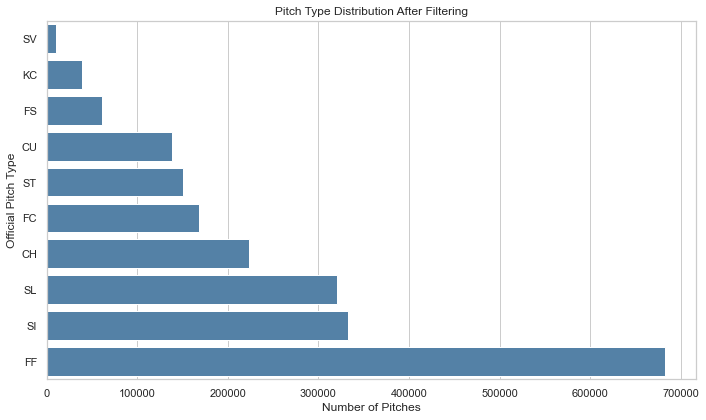

In [4]:
pitch_counts = df['pitch_type'].value_counts()
label_order = pitch_counts.index.tolist()
label_names = [f"{pt} - {PITCH_TYPE_MAP.get(pt, pt)}" for pt in label_order]

class_balance = pd.DataFrame({
    'pitch_type': pitch_counts.index,
    'pitch_name': [PITCH_TYPE_MAP.get(pt, pt) for pt in pitch_counts.index],
    'count': pitch_counts.values,
    'pct_of_data': (pitch_counts.values / len(df) * 100).round(2)
})
display(class_balance)

season_pitch_counts = pd.crosstab(df['season'], df['pitch_type']).loc[:, label_order]
print("Pitch counts by season:")
display(season_pitch_counts)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=class_balance.sort_values('count', ascending=True),
    x='count', y='pitch_type', color='steelblue', ax=ax
)
ax.set_title('Pitch Type Distribution After Filtering')
ax.set_xlabel('Number of Pitches')
ax.set_ylabel('Official Pitch Type')
plt.tight_layout()
plt.show()

## 5. Train/Test Split
Use a stratified split so that the train and test sets preserve the same pitch-type distribution. Random Forests do not require standardization because tree splits are based on feature thresholds rather than distance.

In [5]:
X = df[BALL_FLIGHT_FEATURES].copy()
y = df['pitch_type'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")
print(f"Features:      {X_train.shape[1]}")

print("\nTrain pitch distribution (%):")
print((y_train.value_counts(normalize=True).loc[label_order] * 100).round(2))

print("\nTest pitch distribution (%):")
print((y_test.value_counts(normalize=True).loc[label_order] * 100).round(2))

Training rows: 1,703,392
Test rows:     425,848
Features:      18

Train pitch distribution (%):
FF   32.090
SI   15.640
SL   15.070
CH   10.490
FC    7.930
ST    7.050
CU    6.510
FS    2.900
KC    1.850
SV    0.480
Name: pitch_type, dtype: float64

Test pitch distribution (%):
FF   32.090
SI   15.640
SL   15.070
CH   10.490
FC    7.930
ST    7.050
CU    6.510
FS    2.900
KC    1.850
SV    0.480
Name: pitch_type, dtype: float64


## 6. Baseline: Majority Class
A simple baseline predicts the most common pitch type every time. The Random Forest should substantially outperform this benchmark, especially on balanced accuracy and macro F1.

In [6]:
majority_class = y_train.value_counts().idxmax()
baseline_pred = np.repeat(majority_class, len(y_test))

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)
baseline_macro_f1 = f1_score(y_test, baseline_pred, average='macro')

print(f"Majority class: {majority_class} - {PITCH_TYPE_MAP.get(majority_class, majority_class)}")
print(f"Baseline Accuracy:          {baseline_accuracy:.4f}")
print(f"Baseline Balanced Accuracy: {baseline_balanced_accuracy:.4f}")
print(f"Baseline Macro F1:          {baseline_macro_f1:.4f}")

Majority class: FF - Four-Seam Fastball
Baseline Accuracy:          0.3209
Baseline Balanced Accuracy: 0.1000
Baseline Macro F1:          0.0486


## 7. Random Forest Classifier
Fit a Random Forest to predict the official pitch label. The model can capture nonlinear interactions between velocity, movement, spin, release point, and acceleration without requiring PCA or feature scaling.

In [7]:
rf = RandomForestClassifier(
    n_estimators=250,
    max_features='sqrt',
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=SEED
)

print("Fitting Random Forest model...")
rf.fit(X_train, y_train)
print("Model fitted.")

train_accuracy = rf.score(X_train, y_train)
test_accuracy = rf.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:     {test_accuracy:.4f}")

Fitting Random Forest model...
Model fitted.
Training accuracy: 0.9616
Test accuracy:     0.9115


## 8. Overall Model Performance
Evaluate the model using overall accuracy plus class-sensitive metrics. Macro F1 weights each pitch type equally, while weighted F1 accounts for class frequency.

In [8]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")

report = classification_report(
    y_test, y_pred,
    labels=label_order,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
class_report = report_df.loc[label_names, ['precision', 'recall', 'f1-score', 'support']].copy()
class_report.insert(0, 'pitch_type', label_order)
class_report['support'] = class_report['support'].astype(int)
class_report = class_report.sort_values('f1-score', ascending=False)

display(class_report)

Accuracy:          0.9115
Balanced Accuracy: 0.8759
Macro F1:          0.8737
Weighted F1:       0.9117


,pitch_type,precision,recall,f1-score,support
FF - Four-Seam Fastball,FF,0.973,0.963,0.968,136644
SI - Sinker,SI,0.943,0.940,0.942,66614
CH - Changeup,CH,0.930,0.929,0.929,44678
CU - Curveball,CU,0.902,0.898,0.900,27714
ST - Sweeper,ST,0.835,0.922,0.876,30023
SL - Slider,SL,0.878,0.834,0.856,64175
FS - Split-Finger,FS,0.825,0.856,0.840,12333
KC - Knuckle Curve,KC,0.835,0.817,0.826,7864
FC - Cutter,FC,0.784,0.823,0.803,33754
SV - Slurve,SV,0.817,0.778,0.797,2049


## 9. Confusion Matrix
The normalized confusion matrix shows where the model recreates the official labels cleanly and where similar pitch types overlap.

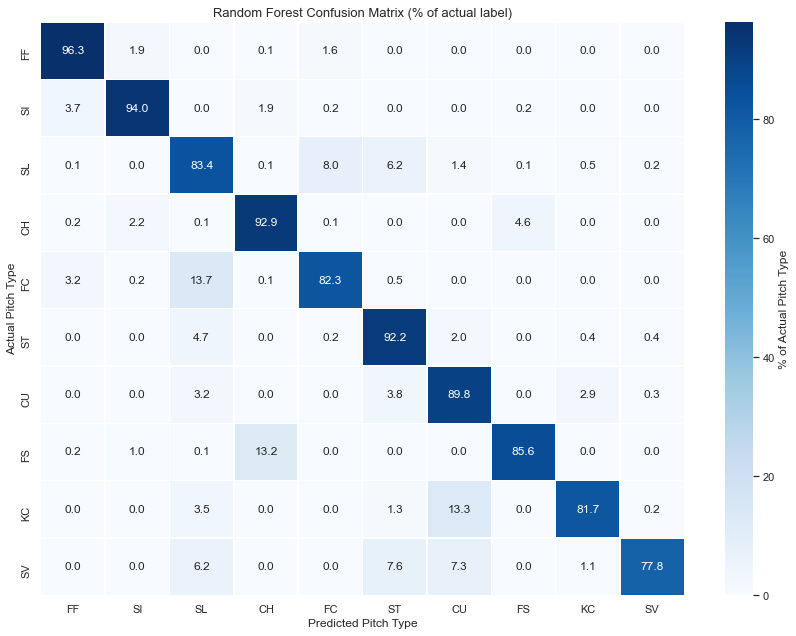

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=label_order)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_pct,
    annot=True, fmt='.1f', cmap='Blues',
    xticklabels=label_order, yticklabels=label_order,
    linewidths=0.4, ax=ax,
    cbar_kws={'label': '% of Actual Pitch Type'}
)
ax.set_title('Random Forest Confusion Matrix (% of actual label)', fontsize=13)
ax.set_xlabel('Predicted Pitch Type')
ax.set_ylabel('Actual Pitch Type')
plt.tight_layout()
plt.show()

## 10. Most Common Misclassifications
Summarize the largest off-diagonal confusion pairs. These errors are useful because they identify pitch labels with similar physical signatures.

,actual,predicted,count,pct_of_actual,actual_name,predicted_name,pair
13,SL,FC,5153,8.030,Slider,Cutter,SL -> FC
26,FC,SL,4614,13.669,Cutter,Slider,FC -> SL
14,SL,ST,3983,6.206,Slider,Sweeper,SL -> ST
0,FF,SI,2599,1.902,Four-Seam Fastball,Sinker,FF -> SI
5,SI,FF,2468,3.705,Sinker,Four-Seam Fastball,SI -> FF
3,FF,FC,2242,1.641,Four-Seam Fastball,Cutter,FF -> FC
23,CH,FS,2035,4.555,Changeup,Split-Finger,CH -> FS
50,FS,CH,1623,13.160,Split-Finger,Changeup,FS -> CH
33,ST,SL,1419,4.726,Sweeper,Slider,ST -> SL
7,SI,CH,1237,1.857,Sinker,Changeup,SI -> CH


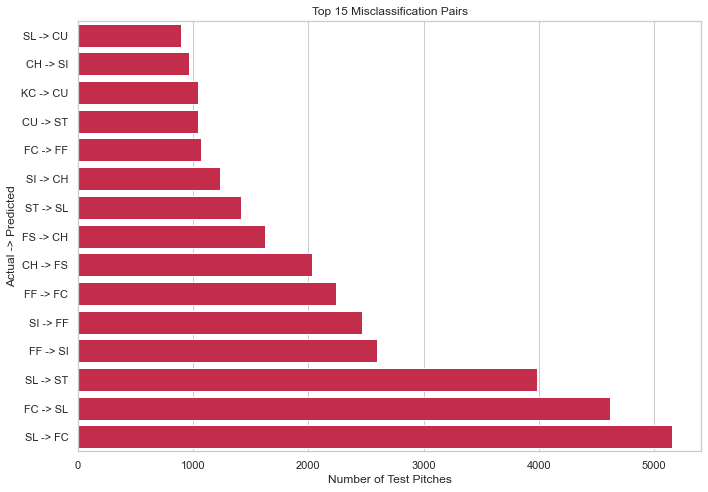

In [10]:
cm_counts = pd.DataFrame(cm, index=label_order, columns=label_order)

errors = []
for actual in label_order:
    for predicted in label_order:
        count = cm_counts.loc[actual, predicted]
        if actual != predicted and count > 0:
            errors.append({
                'actual': actual,
                'predicted': predicted,
                'count': int(count),
                'pct_of_actual': count / cm_counts.loc[actual].sum() * 100
            })

error_df = pd.DataFrame(errors).sort_values('count', ascending=False)
error_df['actual_name'] = error_df['actual'].map(PITCH_TYPE_MAP)
error_df['predicted_name'] = error_df['predicted'].map(PITCH_TYPE_MAP)
error_df['pair'] = error_df['actual'] + ' -> ' + error_df['predicted']

display(error_df.head(15))

top_errors = error_df.head(15).sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_errors, x='count', y='pair', color='crimson', ax=ax)
ax.set_title('Top 15 Misclassification Pairs')
ax.set_xlabel('Number of Test Pitches')
ax.set_ylabel('Actual -> Predicted')
plt.tight_layout()
plt.show()

## 11. Feature Importance
Random Forest impurity-based importance shows which features the trees used most often to separate pitch labels. This is model-specific, but it is a good first check against baseball intuition.

,feature,importance
2,release_spin_rate,0.129
17,az,0.099
5,pfx_z,0.094
3,spin_axis,0.090
4,pfx_x,0.085
15,ax,0.083
8,release_pos_x,0.072
10,release_pos_z,0.058
0,release_speed,0.058
13,vy0,0.056


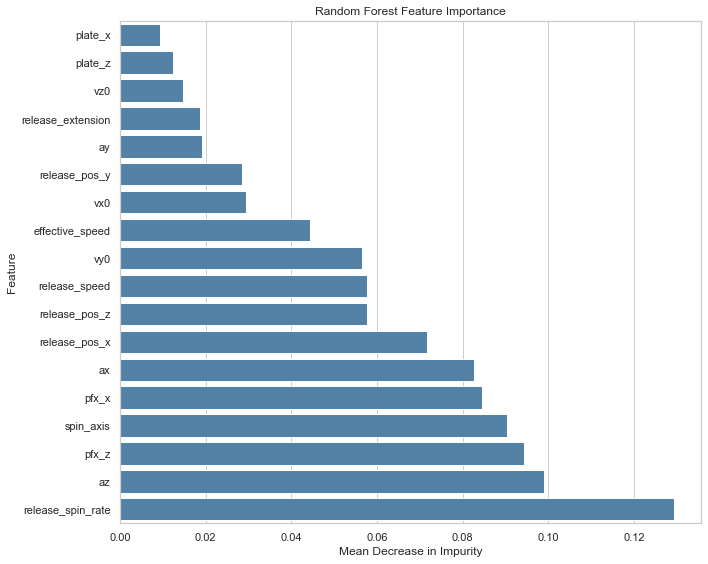

In [11]:
feature_importance = pd.DataFrame({
    'feature': BALL_FLIGHT_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=feature_importance.sort_values('importance', ascending=True),
    x='importance', y='feature', color='steelblue', ax=ax
)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 12. Permutation Importance
Permutation importance measures performance loss when each feature is shuffled. This provides a model-agnostic check and helps guard against over-interpreting impurity-based importance.

Running permutation importance on 7,500 held-out pitches...


,feature,importance_mean,importance_std
2,release_spin_rate,0.160,0.002
8,release_pos_x,0.142,0.003
3,spin_axis,0.140,0.004
10,release_pos_z,0.100,0.001
5,pfx_z,0.092,0.003
17,az,0.078,0.001
4,pfx_x,0.057,0.004
15,ax,0.052,0.002
9,release_pos_y,0.033,0.000
0,release_speed,0.027,0.000


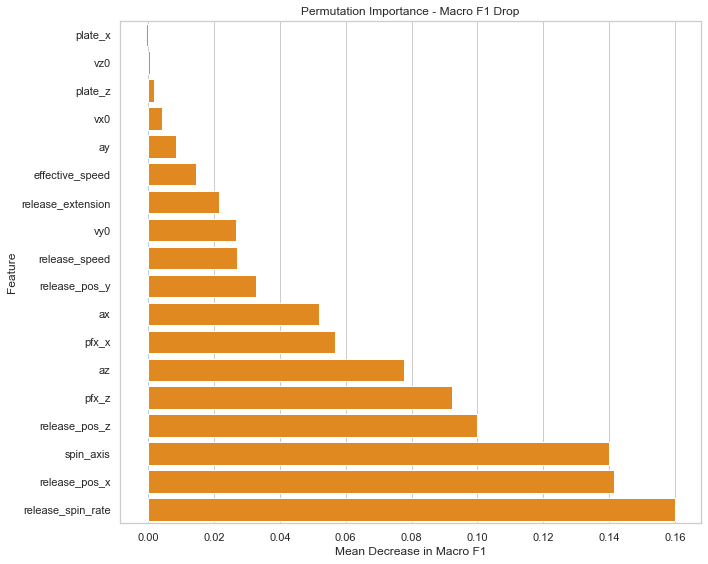

In [12]:
PERM_SAMPLE_SIZE = min(7500, len(X_test))
X_perm = X_test.sample(n=PERM_SAMPLE_SIZE, random_state=SEED)
y_perm = y_test.loc[X_perm.index]

print(f"Running permutation importance on {PERM_SAMPLE_SIZE:,} held-out pitches...")
perm = permutation_importance(
    rf,
    X_perm,
    y_perm,
    n_repeats=2,
    random_state=SEED,
    scoring='f1_macro',
    n_jobs=1
)

perm_importance = pd.DataFrame({
    'feature': BALL_FLIGHT_FEATURES,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_importance)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=perm_importance.sort_values('importance_mean', ascending=True),
    x='importance_mean', y='feature', color='darkorange', ax=ax
)
ax.set_title('Permutation Importance - Macro F1 Drop')
ax.set_xlabel('Mean Decrease in Macro F1')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 13. Evaluation by Pitcher Handedness
Because horizontal movement mirrors across pitcher handedness, check whether the model recreates labels equally well for RHP and LHP pitches.

,test_pitches,accuracy,balanced_accuracy,macro_f1
p_throws,,,,
L,114851,0.928,0.896,0.896
R,310997,0.905,0.864,0.864


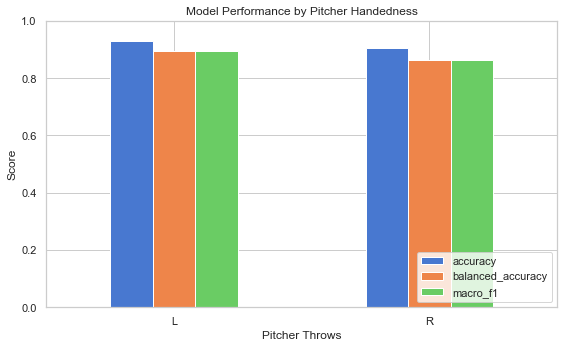

In [13]:
test_meta = df.loc[X_test.index, ['p_throws', 'season']].copy()
eval_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'p_throws': test_meta['p_throws'].values,
    'season': test_meta['season'].values
})

handedness_rows = []
for hand, group in eval_df.groupby('p_throws'):
    handedness_rows.append({
        'p_throws': hand,
        'test_pitches': len(group),
        'accuracy': accuracy_score(group['actual'], group['predicted']),
        'balanced_accuracy': balanced_accuracy_score(group['actual'], group['predicted']),
        'macro_f1': f1_score(group['actual'], group['predicted'], average='macro')
    })

handedness_eval = pd.DataFrame(handedness_rows).set_index('p_throws')
display(handedness_eval)

fig, ax = plt.subplots(figsize=(8, 5))
handedness_eval[['accuracy', 'balanced_accuracy', 'macro_f1']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance by Pitcher Handedness')
ax.set_xlabel('Pitcher Throws')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Evaluation by Season
The model is trained on the combined 2023-2025 dataset. Checking held-out performance by season helps identify whether label reconstruction is stable across years.

,test_pitches,accuracy,balanced_accuracy,macro_f1
season,,,,
2023,141646,0.905,0.875,0.866
2024,143297,0.915,0.883,0.881
2025,140905,0.914,0.871,0.873


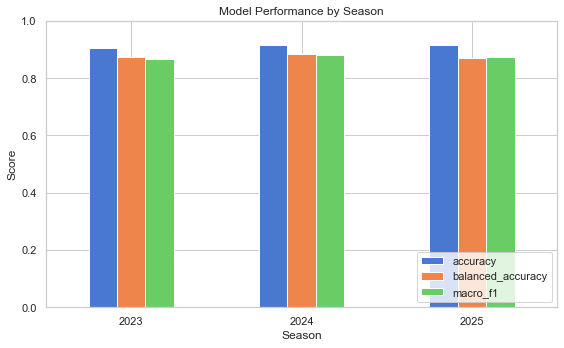

In [14]:
season_rows = []
for season, group in eval_df.groupby('season'):
    season_rows.append({
        'season': season,
        'test_pitches': len(group),
        'accuracy': accuracy_score(group['actual'], group['predicted']),
        'balanced_accuracy': balanced_accuracy_score(group['actual'], group['predicted']),
        'macro_f1': f1_score(group['actual'], group['predicted'], average='macro')
    })

season_eval = pd.DataFrame(season_rows).set_index('season').sort_index()
display(season_eval)

fig, ax = plt.subplots(figsize=(8, 5))
season_eval[['accuracy', 'balanced_accuracy', 'macro_f1']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Prediction Confidence
Use predicted probabilities to see whether the model is most accurate when it is most confident. Low-confidence predictions often correspond to borderline pitch labels.

,confidence_bin,pitches,accuracy,mean_confidence
0,"(0.1, 0.2]",1,0.000,0.198
1,"(0.2, 0.3]",178,0.331,0.279
2,"(0.3, 0.4]",2599,0.435,0.365
3,"(0.4, 0.5]",10635,0.550,0.463
4,"(0.5, 0.6]",30678,0.624,0.551
5,"(0.6, 0.7]",34951,0.761,0.652
6,"(0.7, 0.8]",46394,0.871,0.753
7,"(0.8, 0.9]",69810,0.946,0.854
8,"(0.9, 1.0]",230602,0.993,0.971


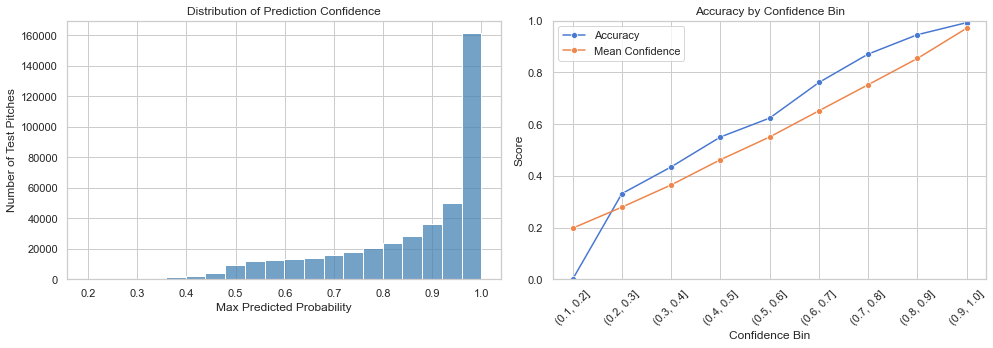

In [15]:
proba = rf.predict_proba(X_test)
confidence = proba.max(axis=1)

confidence_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'confidence': confidence
})
confidence_df['correct'] = confidence_df['actual'] == confidence_df['predicted']
confidence_df['confidence_bin'] = pd.cut(
    confidence_df['confidence'],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

confidence_summary = (
    confidence_df
    .groupby('confidence_bin', observed=True)
    .agg(
        pitches=('correct', 'size'),
        accuracy=('correct', 'mean'),
        mean_confidence=('confidence', 'mean')
    )
    .reset_index()
)

display(confidence_summary)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(confidence_df['confidence'], bins=20, color='steelblue', ax=ax1)
ax1.set_title('Distribution of Prediction Confidence')
ax1.set_xlabel('Max Predicted Probability')
ax1.set_ylabel('Number of Test Pitches')

plot_summary = confidence_summary.copy()
plot_summary['bin_label'] = plot_summary['confidence_bin'].astype(str)
sns.lineplot(data=plot_summary, x='bin_label', y='accuracy', marker='o', ax=ax2, label='Accuracy')
sns.lineplot(data=plot_summary, x='bin_label', y='mean_confidence', marker='o', ax=ax2, label='Mean Confidence')
ax2.set_title('Accuracy by Confidence Bin')
ax2.set_xlabel('Confidence Bin')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

## 16. Alternative Model: Hist Gradient Boosting
To test whether the pitch-label results are specific to Random Forest, fit a Hist Gradient Boosting classifier on the same train/test split and same ball-flight features. Random Forest averages many independently grown trees, while gradient boosting builds small trees sequentially so each new tree focuses on errors from the current ensemble.

In [16]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

hgb = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=0.10,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    random_state=SEED
)

hgb_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

print('Fitting Hist Gradient Boosting model...')
hgb.fit(X_train, y_train, sample_weight=hgb_sample_weight)
print('Model fitted.')

Fitting Hist Gradient Boosting model...
Model fitted.


## 17. Random Forest vs. Hist Gradient Boosting
Both models answer the same supervised question: can Statcast ball-flight features recreate the official MLB pitch-type label? Positive deltas below mean Hist Gradient Boosting outperformed Random Forest on the held-out test set.

,accuracy,balanced_accuracy,macro_f1,weighted_f1
Majority Class Baseline,0.321,0.100,0.049,0.156
Random Forest,0.911,0.876,0.874,0.912
Hist Gradient Boosting,0.884,0.877,0.824,0.887


,hgb_minus_random_forest
accuracy,-0.027
balanced_accuracy,0.001
macro_f1,-0.050
weighted_f1,-0.025


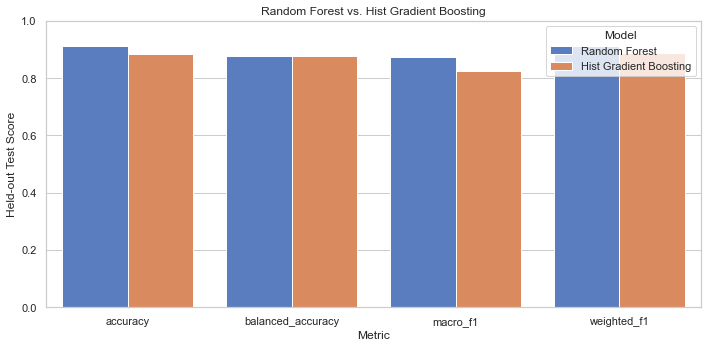

Comparison summary:
Best macro F1: Random Forest (0.8737)
Best weighted F1: Random Forest (0.9117)
Hist Gradient Boosting minus Random Forest macro F1: -0.0497
Hist Gradient Boosting minus Random Forest balanced accuracy: +0.0009


In [17]:
hgb_pred = hgb.predict(X_test)

def summarize_model_performance(y_true, y_hat):
    return pd.Series({
        'accuracy': accuracy_score(y_true, y_hat),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_hat),
        'macro_f1': f1_score(y_true, y_hat, average='macro'),
        'weighted_f1': f1_score(y_true, y_hat, average='weighted')
    })

model_comparison = pd.DataFrame({
    'Majority Class Baseline': summarize_model_performance(y_test, baseline_pred),
    'Random Forest': summarize_model_performance(y_test, y_pred),
    'Hist Gradient Boosting': summarize_model_performance(y_test, hgb_pred)
}).T

delta_summary = (
    model_comparison.loc['Hist Gradient Boosting']
    - model_comparison.loc['Random Forest']
).to_frame('hgb_minus_random_forest')

display(model_comparison)
display(delta_summary)

comparison_plot = (
    model_comparison
    .loc[['Random Forest', 'Hist Gradient Boosting'], ['accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']]
    .reset_index()
    .melt(id_vars='index', var_name='metric', value_name='score')
    .rename(columns={'index': 'model'})
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=comparison_plot, x='metric', y='score', hue='model', ax=ax)
ax.set_title('Random Forest vs. Hist Gradient Boosting')
ax.set_xlabel('Metric')
ax.set_ylabel('Held-out Test Score')
ax.set_ylim(0, 1)
ax.legend(title='Model')
plt.tight_layout()
plt.show()

best_macro_model = model_comparison['macro_f1'].idxmax()
best_weighted_model = model_comparison['weighted_f1'].idxmax()
best_macro_score = model_comparison.loc[best_macro_model, 'macro_f1']
best_weighted_score = model_comparison.loc[best_weighted_model, 'weighted_f1']

print('Comparison summary:')
print(f'Best macro F1: {best_macro_model} ({best_macro_score:.4f})')
print(f'Best weighted F1: {best_weighted_model} ({best_weighted_score:.4f})')
print(f"Hist Gradient Boosting minus Random Forest macro F1: {delta_summary.loc['macro_f1', 'hgb_minus_random_forest']:+.4f}")
print(f"Hist Gradient Boosting minus Random Forest balanced accuracy: {delta_summary.loc['balanced_accuracy', 'hgb_minus_random_forest']:+.4f}")

## 18. Class-Level Comparison
Overall metrics can hide whether one model is better only on common pitch types. This table compares F1 by pitch type so the model tradeoffs are visible by class.

,pitch_type,pitch_name,support,random_forest_f1,hist_gradient_boosting_f1,hgb_minus_rf_f1
1,SI,Sinker,66614,0.942,0.934,-0.008
0,FF,Four-Seam Fastball,136644,0.968,0.959,-0.009
5,ST,Sweeper,30023,0.876,0.855,-0.021
3,CH,Changeup,44678,0.929,0.900,-0.029
4,FC,Cutter,33754,0.803,0.771,-0.032
6,CU,Curveball,27714,0.900,0.855,-0.045
2,SL,Slider,64175,0.856,0.810,-0.046
7,FS,Split-Finger,12333,0.840,0.781,-0.059
8,KC,Knuckle Curve,7864,0.826,0.731,-0.094
9,SV,Slurve,2049,0.797,0.644,-0.154


Hist Gradient Boosting has higher F1 on 0 pitch types; Random Forest has higher F1 on 10; ties: 0.


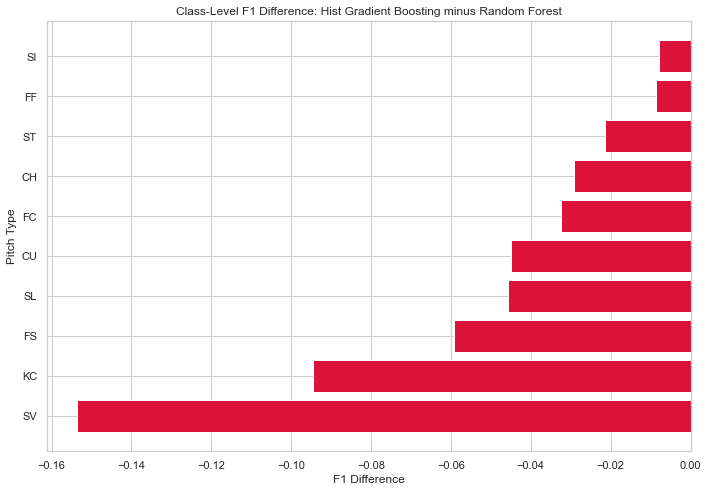

In [18]:
rf_class_metrics = pd.DataFrame(
    classification_report(y_test, y_pred, labels=label_order, output_dict=True, zero_division=0)
).T.loc[label_order]

hgb_class_metrics = pd.DataFrame(
    classification_report(y_test, hgb_pred, labels=label_order, output_dict=True, zero_division=0)
).T.loc[label_order]

class_model_comparison = pd.DataFrame({
    'pitch_type': label_order,
    'pitch_name': [PITCH_TYPE_MAP.get(pt, pt) for pt in label_order],
    'support': rf_class_metrics['support'].astype(int).values,
    'random_forest_f1': rf_class_metrics['f1-score'].values,
    'hist_gradient_boosting_f1': hgb_class_metrics['f1-score'].values
})

class_model_comparison['hgb_minus_rf_f1'] = (
    class_model_comparison['hist_gradient_boosting_f1']
    - class_model_comparison['random_forest_f1']
)
class_model_comparison = class_model_comparison.sort_values('hgb_minus_rf_f1', ascending=False)

display(class_model_comparison)

hgb_better_classes = (class_model_comparison['hgb_minus_rf_f1'] > 0).sum()
rf_better_classes = (class_model_comparison['hgb_minus_rf_f1'] < 0).sum()
tied_classes = (class_model_comparison['hgb_minus_rf_f1'] == 0).sum()

print(
    f'Hist Gradient Boosting has higher F1 on {hgb_better_classes} pitch types; '
    f'Random Forest has higher F1 on {rf_better_classes}; ties: {tied_classes}.'
)

plot_class_delta = class_model_comparison.sort_values('hgb_minus_rf_f1')
bar_colors = np.where(plot_class_delta['hgb_minus_rf_f1'] >= 0, 'seagreen', 'crimson')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_class_delta['pitch_type'], plot_class_delta['hgb_minus_rf_f1'], color=bar_colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Class-Level F1 Difference: Hist Gradient Boosting minus Random Forest')
ax.set_xlabel('F1 Difference')
ax.set_ylabel('Pitch Type')
plt.tight_layout()
plt.show()

## 19. Third Model: Multinomial Logistic Regression
As a simpler contrast to both tree ensembles, fit a multinomial logistic regression model. Logistic regression uses linear decision boundaries, so it tests whether pitch labels can be recovered from relatively direct weighted combinations of the ball-flight features. Because logistic regression is scale-sensitive, the model uses standardization inside a pipeline.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED
    ))
])

print('Fitting Multinomial Logistic Regression model...')
log_reg.fit(X_train, y_train)
print('Model fitted.')

Fitting Multinomial Logistic Regression model...
Model fitted.


## 20. Three-Model Comparison
Compare Random Forest, Hist Gradient Boosting, and Multinomial Logistic Regression on the same held-out test set. If logistic regression is close to the tree ensembles, the pitch labels are mostly linearly separable from the selected features. If it trails badly, that supports the value of nonlinear interactions captured by the tree models.

,accuracy,balanced_accuracy,macro_f1,weighted_f1
Majority Class Baseline,0.321,0.100,0.049,0.156
Random Forest,0.911,0.876,0.874,0.912
Hist Gradient Boosting,0.884,0.877,0.824,0.887
Multinomial Logistic Regression,0.724,0.667,0.600,0.737


,accuracy,balanced_accuracy,macro_f1,weighted_f1
Random Forest,1,2,1,1
Hist Gradient Boosting,2,1,2,2
Multinomial Logistic Regression,3,3,3,3


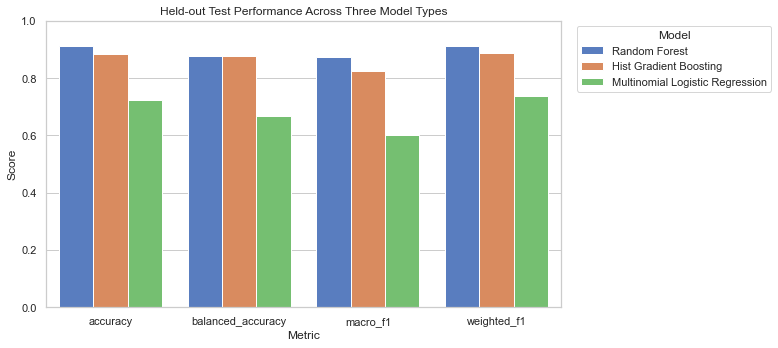

Best model by metric:
accuracy: Random Forest (0.9115)
balanced_accuracy: Hist Gradient Boosting (0.8767)
macro_f1: Random Forest (0.8737)
weighted_f1: Random Forest (0.9117)

Logistic Regression gaps:
accuracy: vs Random Forest -0.1870; vs Hist Gradient Boosting -0.1600
balanced_accuracy: vs Random Forest -0.2084; vs Hist Gradient Boosting -0.2092
macro_f1: vs Random Forest -0.2733; vs Hist Gradient Boosting -0.2236
weighted_f1: vs Random Forest -0.1749; vs Hist Gradient Boosting -0.1498


In [20]:
log_reg_pred = log_reg.predict(X_test)

all_model_comparison = pd.DataFrame({
    'Majority Class Baseline': summarize_model_performance(y_test, baseline_pred),
    'Random Forest': summarize_model_performance(y_test, y_pred),
    'Hist Gradient Boosting': summarize_model_performance(y_test, hgb_pred),
    'Multinomial Logistic Regression': summarize_model_performance(y_test, log_reg_pred)
}).T

display(all_model_comparison)

three_model_scores = all_model_comparison.loc[
    ['Random Forest', 'Hist Gradient Boosting', 'Multinomial Logistic Regression']
]

three_model_rankings = three_model_scores.rank(ascending=False, method='min').astype(int)
display(three_model_rankings)

three_model_plot = (
    three_model_scores
    .reset_index()
    .melt(id_vars='index', var_name='metric', value_name='score')
    .rename(columns={'index': 'model'})
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=three_model_plot, x='metric', y='score', hue='model', ax=ax)
ax.set_title('Held-out Test Performance Across Three Model Types')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Best model by metric:')
for metric in three_model_scores.columns:
    best_model = three_model_scores[metric].idxmax()
    best_score = three_model_scores.loc[best_model, metric]
    print(f'{metric}: {best_model} ({best_score:.4f})')

print('\nLogistic Regression gaps:')
for metric in three_model_scores.columns:
    log_vs_rf = three_model_scores.loc['Multinomial Logistic Regression', metric] - three_model_scores.loc['Random Forest', metric]
    log_vs_hgb = three_model_scores.loc['Multinomial Logistic Regression', metric] - three_model_scores.loc['Hist Gradient Boosting', metric]
    print(f'{metric}: vs Random Forest {log_vs_rf:+.4f}; vs Hist Gradient Boosting {log_vs_hgb:+.4f}')

## 21. Three-Model Class-Level Comparison
Finally, compare F1 score by pitch type across all three models. This shows whether one model is strongest overall or whether performance depends on the specific pitch category.

,pitch_type,pitch_name,support,random_forest_f1,hist_gradient_boosting_f1,logistic_regression_f1,best_model,best_f1,tree_ensemble_advantage_over_log_reg
9,SV,Slurve,2049,0.797,0.644,0.143,Random Forest,0.797,0.655
8,KC,Knuckle Curve,7864,0.826,0.731,0.394,Random Forest,0.826,0.432
3,CH,Changeup,44678,0.929,0.900,0.662,Random Forest,0.929,0.267
6,CU,Curveball,27714,0.900,0.855,0.652,Random Forest,0.900,0.248
7,FS,Split-Finger,12333,0.840,0.781,0.604,Random Forest,0.840,0.236
2,SL,Slider,64175,0.856,0.810,0.621,Random Forest,0.856,0.234
5,ST,Sweeper,30023,0.876,0.855,0.645,Random Forest,0.876,0.231
4,FC,Cutter,33754,0.803,0.771,0.592,Random Forest,0.803,0.211
1,SI,Sinker,66614,0.942,0.934,0.784,Random Forest,0.942,0.158
0,FF,Four-Seam Fastball,136644,0.968,0.959,0.906,Random Forest,0.968,0.061


Random Forest    10
Name: pitch_types_won, dtype: int64

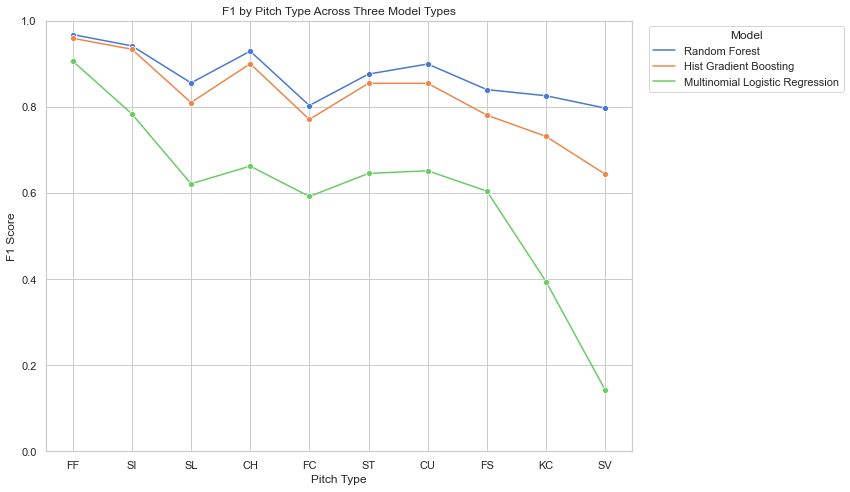

In [21]:
log_reg_class_metrics = pd.DataFrame(
    classification_report(y_test, log_reg_pred, labels=label_order, output_dict=True, zero_division=0)
).T.loc[label_order]

three_model_class_comparison = pd.DataFrame({
    'pitch_type': label_order,
    'pitch_name': [PITCH_TYPE_MAP.get(pt, pt) for pt in label_order],
    'support': rf_class_metrics['support'].astype(int).values,
    'random_forest_f1': rf_class_metrics['f1-score'].values,
    'hist_gradient_boosting_f1': hgb_class_metrics['f1-score'].values,
    'logistic_regression_f1': log_reg_class_metrics['f1-score'].values
})

f1_columns = ['random_forest_f1', 'hist_gradient_boosting_f1', 'logistic_regression_f1']
model_name_map = {
    'random_forest_f1': 'Random Forest',
    'hist_gradient_boosting_f1': 'Hist Gradient Boosting',
    'logistic_regression_f1': 'Multinomial Logistic Regression'
}

three_model_class_comparison['best_model'] = (
    three_model_class_comparison[f1_columns]
    .idxmax(axis=1)
    .map(model_name_map)
)
three_model_class_comparison['best_f1'] = three_model_class_comparison[f1_columns].max(axis=1)
three_model_class_comparison['tree_ensemble_advantage_over_log_reg'] = (
    three_model_class_comparison[['random_forest_f1', 'hist_gradient_boosting_f1']].max(axis=1)
    - three_model_class_comparison['logistic_regression_f1']
)

display(
    three_model_class_comparison
    .sort_values('tree_ensemble_advantage_over_log_reg', ascending=False)
)

display(three_model_class_comparison['best_model'].value_counts().rename('pitch_types_won'))

class_plot_data = (
    three_model_class_comparison
    .melt(
        id_vars=['pitch_type', 'pitch_name', 'support'],
        value_vars=f1_columns,
        var_name='model',
        value_name='f1_score'
    )
)
class_plot_data['model'] = class_plot_data['model'].map(model_name_map)

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(data=class_plot_data, x='pitch_type', y='f1_score', hue='model', marker='o', ax=ax)
ax.set_title('F1 by Pitch Type Across Three Model Types')
ax.set_xlabel('Pitch Type')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()